##  Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/amazon.csv")

In [8]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')

In [9]:
df.shape

(1465, 16)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [11]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [35]:
df['product_id'].nunique()

1351

In [13]:
df['user_id'].nunique()

1194

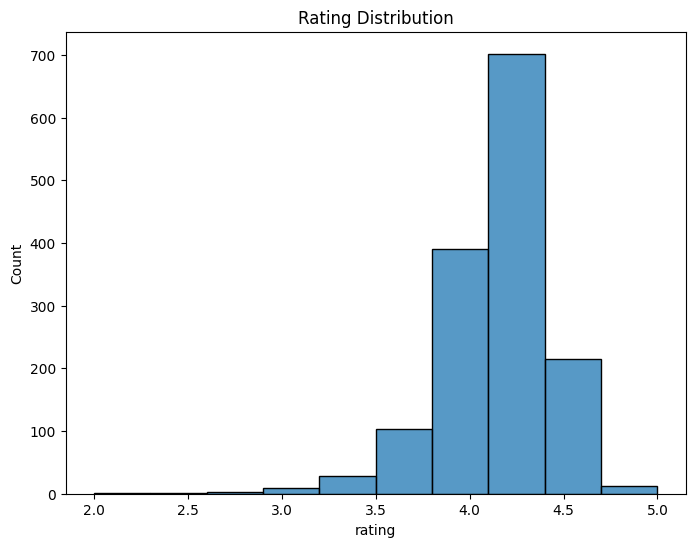

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(df['rating'],bins=10)
plt.title("Rating Distribution")
plt.show()

In [26]:
df['category'].value_counts().head(10)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        233
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                      68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                             63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              52
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  27
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice                            24
Home&Kitch

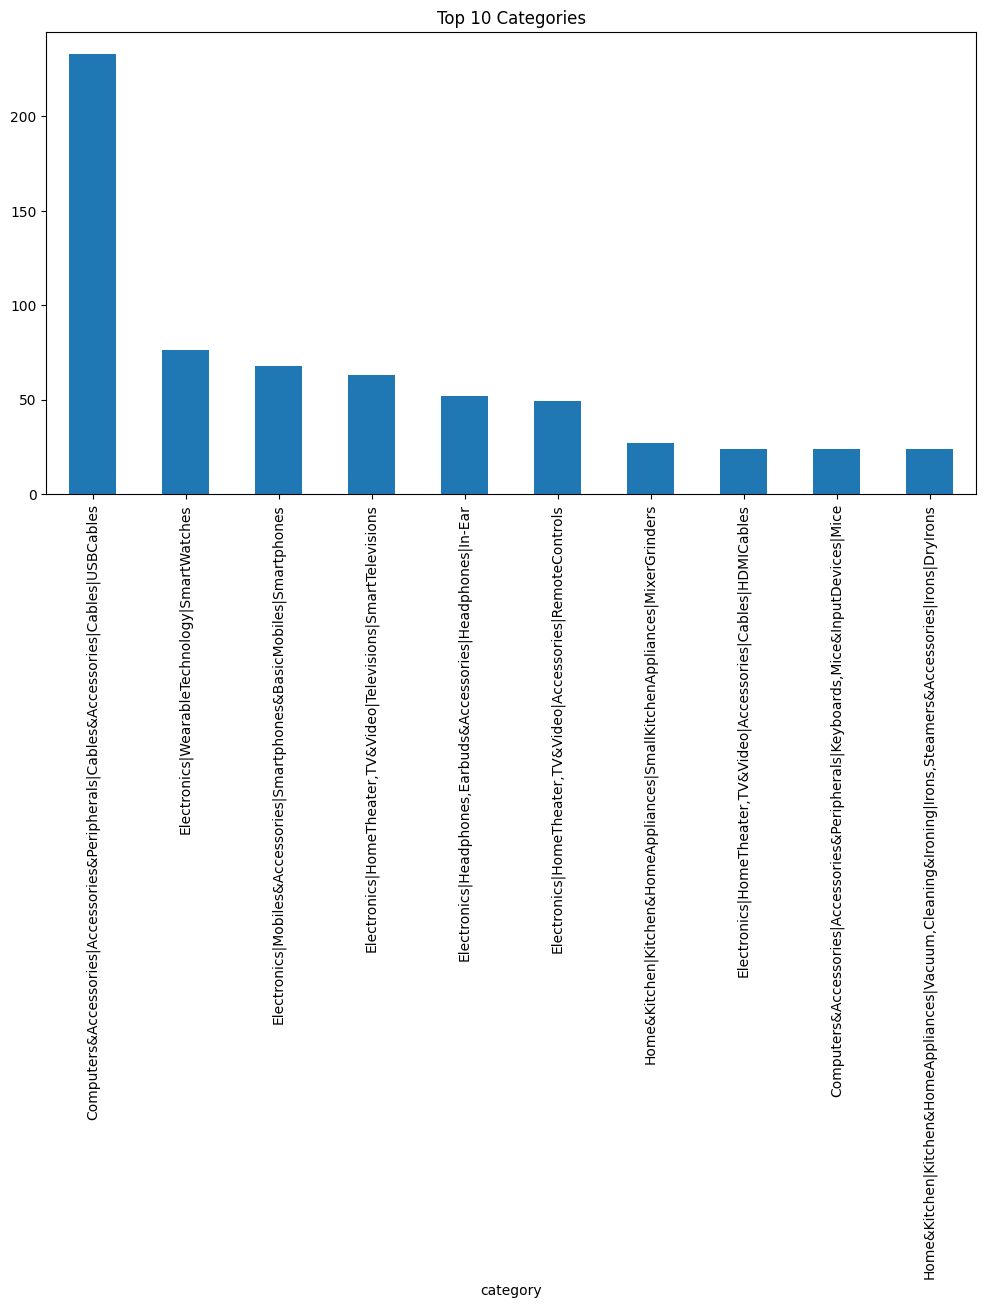

In [49]:
plt.figure(figsize=(12,6))
top_categories = df['category'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.title("Top 10 Categories")
plt.xticks(rotation=90)
plt.show()

In [37]:
df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',', '')
)

df['rating_count'] = pd.to_numeric(
    df['rating_count'],
    errors='coerce'
)

In [30]:
top_products = df.sort_values(
    by='rating_count',
    ascending=False
)

top_products[
    ['product_name','rating_count']
].head(10)

,product_name,rating_count
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0
566,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",313832.0


In [40]:
df['rating'].dtype

<StringDtype(storage='python', na_value=nan)>

In [41]:
df['rating'].unique()

<StringArray>
['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3', '3.6', '3.4',
 '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0', '2.8',   '4', '3.1', '4.8',
 '2.3',   '|',   '2',   '3', '2.6', '2.9']
Length: 28, dtype: str

In [42]:
df['rating'] = pd.to_numeric(
    df['rating'],
    errors='coerce'
)

In [43]:
df['rating'].dtype

dtype('float64')

In [44]:
df['rating'].isnull().sum()

np.int64(1)

In [ ]:
df['rating'].mean()

np.float64(4.096584699453552)